## Encontrando patrones en una imagen en blanco y negro

Dada la imagen que os he dejado en el aula virtual, que tiene repartidos simbolos "más" (+) de forma aleatoria:

1. Carga la imagen
2. Construye una matriz de 3x3 que represente un símbolo "+" como los de la imagen
3. Programa una función que encuentre dicho patrón en la imagen
4. Ve guardando las posiciones (coordenadas) donde están los "mases" en otra matrix y representa los datos con matplotlib

# 1. Carga la imagen

Text(0.5, 1.0, 'Imagen Original')

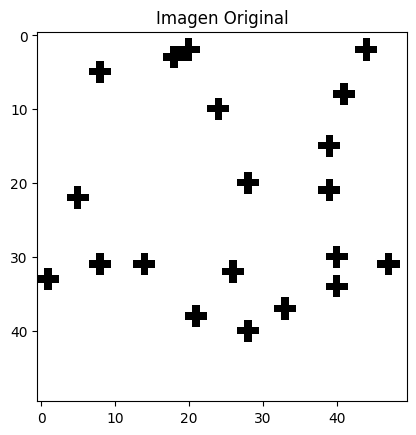

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Cargar 7_2_imagen.png
img = plt.imread('7_2_imagen.png')
# Mostrar la imagen original
plt.imshow(img)
plt.title('Imagen Original')

Text(0.5, 1.0, 'Simbolo +')

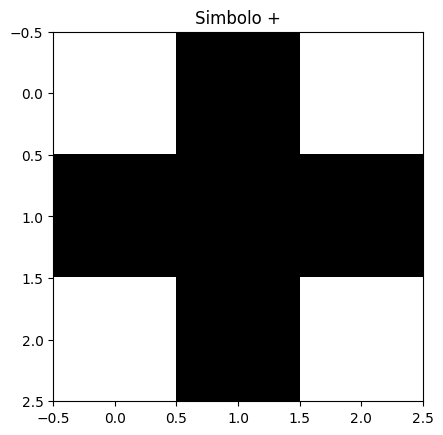

In [4]:
#2. Construye una matriz 3x3 que represente un simbolo '+' como los de la imagen.
tamanio = (3, 3)
simbolo_mas = np.array([[1, 0, 1],
                        [0, 0, 0],
                        [1, 0, 1]])
#Mostrar 
plt.imshow(simbolo_mas, cmap='gray')
plt.title('Simbolo +')

El simbolo "+" se encuentra en la posición: (1, 43)
Las posiciones donde se encuentran los símbolos "+" son: [(1, 43), (4, 7), (7, 40), (9, 23), (14, 38), (19, 27), (20, 38), (21, 4), (29, 39), (30, 7), (30, 13), (30, 46), (31, 25), (32, 0), (33, 39), (36, 32), (37, 20), (39, 27)]


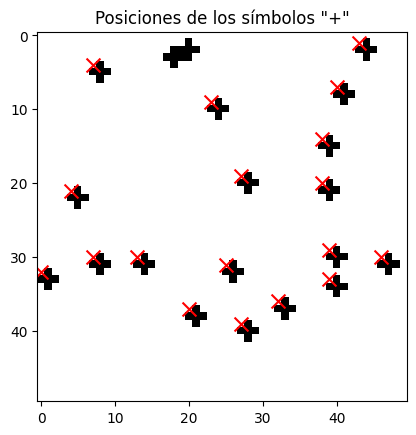

In [10]:
#3. Programar una funcion que encuentre el  simbolo '+' en una imagen
def encontrar_simbolo_mas(imagen, simbolo):
    # Si la imagen tiene canales (RGB/RGBA), convertir a 2D usando el primer canal
    if imagen.ndim == 3:
        imagen_proc = imagen[..., 0]
    else:
        imagen_proc = imagen

    # Obtener las dimensiones de la imagen procesada y del simbolo
    img_height, img_width = imagen_proc.shape
    simbolo_height, simbolo_width = simbolo.shape
    
    # Recorrer la imagen para encontrar el simbolo
    for i in range(img_height - simbolo_height + 1):
        for j in range(img_width - simbolo_width + 1):
            
            submatriz = imagen_proc[i:i+simbolo_height, j:j+simbolo_width]
            # Comparar la submatriz con el simbolo
            if np.array_equal(submatriz, simbolo):
                return (i, j)  # Retornar la posición donde se encontró el simbolo
            
    return None  # Retornar None si no se encuentra el simbolo

#4. Usar la funcion para encontrar el simbolo '+' en la imagen cargada
posicion = encontrar_simbolo_mas(img, simbolo_mas)
print(f'El simbolo "+" se encuentra en la posición: {posicion}')

#Ve guardando las posiciones (coordenadas) donde están los "mases" en otra matrix y representa los datos con matplotlib
posiciones = []
def encontrar_todas_posiciones(imagen, simbolo):
    # Si la imagen tiene canales (RGB/RGBA), convertir a 2D usando el primer canal
    if imagen.ndim == 3:
        imagen_proc = imagen[..., 0]
    else:
        imagen_proc = imagen

    # Obtener las dimensiones de la imagen procesada y del simbolo
    img_height, img_width = imagen_proc.shape
    simbolo_height, simbolo_width = simbolo.shape
    
    # Recorrer la imagen para encontrar el simbolo
    for i in range(img_height - simbolo_height + 1):
        for j in range(img_width - simbolo_width + 1):
            
            submatriz = imagen_proc[i:i+simbolo_height, j:j+simbolo_width]
            # Comparar la submatriz con el simbolo
            if np.array_equal(submatriz, simbolo):
                posiciones.append((i, j))  # Guardar la posición donde se encontró el simbolo

encontrar_todas_posiciones(img, simbolo_mas)
print(f'Las posiciones donde se encuentran los símbolos "+" son: {posiciones}')

# Representar las posiciones con matplotlib
x_coords = [pos[1] for pos in posiciones]
y_coords = [pos[0] for pos in posiciones]

plt.scatter(x_coords, y_coords, c='red', marker='x', s=100)
plt.imshow(img, cmap='gray')
plt.title('Posiciones de los símbolos "+"')
plt.show()